## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Nina Breen

**Date:** 9/29/26

**Q1**

**1. What is the difference between regression and classification?**

Regression predicts a numeric outcome while a classification predicts a category.

**2. What is a confusion table? What does it help us understand about a model's performance?**

A confusion table is a counts table showing the count predictions by actual vs predicted class. It shows false positives, false negatives, true positives, and true negatives. It helps with understanding a model's performance because it shows the distribution of type 1 or type 2 errors and how many correct values the model has predicted. 

**3. What does the SSE quantify about a particular model?**

Sum of Squared Error quantifies the residual error, direction and size of a prediction error, between a models predicted point and the actual data point. A lower SSE means that there is less error and the model is performing well.

**4. What are overfitting and underfitting?**

Overfitting is when the model uses the noise and outliers in the training data as the truth and makes predictions based on the noise leading to many errors on an unseen data set. This happens when k is too small. Underfitting is when k is too large leading to basically the same prediction for all observations. This is because it fails to learn relationships.

**5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?**

The model learns on the training data and is tested on the testing set. Splitting the data allows the model to be tested to determine if it is just memorizing the training data or if it is learning the actual relationship of the data. The test set is unseen data to the model and can show if the model is under or overfit based on the k value. By measuring the SSE or accuracy on the test set, you can objectively evaluate the model's true predictive power since it has never seen this data. If we were to base k off of the training data, the model would be overfitted. 

**6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.**

Reporting a class as a prediction is when the data uses the most common class to determine the predicted class. A strength of this is that it is easy to understand and interpret because we are given only one answer as the prediction. Weaknesses of this method include it will likely miss the minor classes and predictions that are almost 50/50 probability look like definite predictions even though the model might have been torn between two different classes. A strength for reporting a class as a probability distribution is showing the model's confidence which is important to show if one is making risk dependent decisions based on the model. A weakness of this method is that it takes more analysis to make a decision based on the model and the probabilities that are given are typically based on the k value not just the prediction.


<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB


array([[<Axes: title={'center': 'voltage'}>,
        <Axes: title={'center': 'height'}>],
       [<Axes: title={'center': 'soil'}>,
        <Axes: title={'center': 'mine_type'}>]], dtype=object)

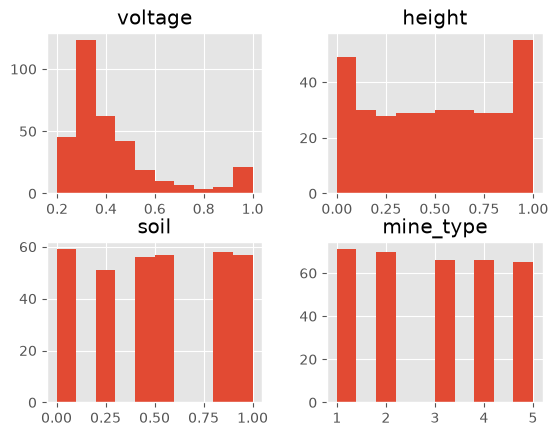

In [52]:
# Q2: 1 - loading the data + exploritory analysis
import pandas as pd

df = pd.read_csv('./data/land_mines.csv')
df = df.copy() # making a copy to not overide the original data
df.info() # shows taht the data types are int or float and there is no null values to be delt with so the data is clean are ready for use
df.describe() # seems like coltage, height, and soil are all bounded between 0-1 and mine types is 1 - 5
df['mine_type'].value_counts() # seems like there is a good balance between the different mine types (range from 65 - 71 counts for each)

df.hist()

# the target is mine type and the features are voltage, height, and soil

In [53]:
# 2 - split the data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# splitting the values: - slitting the data 50/50
eval_feat_raw = df[['voltage', 'height', 'soil']]
eval_target = df['mine_type']
(eval_feat_train_raw, eval_feat_valid_raw, eval_target_train, eval_target_valid) = train_test_split(eval_feat_raw, eval_target, test_size = 0.5, random_state = 7)

#scaling the values: - even though the values are already scaled from 0-1 basically (as shown above) it is a good practive to scale the data no matter what
eval_scaler = MinMaxScaler()
eval_feat_train_scaled = eval_scaler.fit_transform(eval_feat_train_raw)
eval_feat_valid_scaled = eval_scaler.transform(eval_feat_valid_raw)

Text(0.5, 1.0, 'Effect of K')

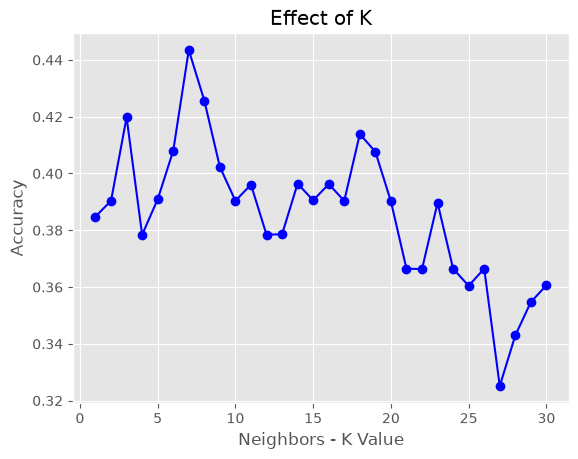

In [54]:
# 3 - build k-NN classifier - selecting k // to determine the best k value, you must do multifitting

import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

k_values = list(range(1, 31)) # From 1 to 30
acc_scores = []
for k in k_values:
  KNN = KNeighborsClassifier(n_neighbors=k)
  scores = cross_val_score(KNN, eval_feat_train_scaled, eval_target_train,
                           scoring='accuracy', cv=5)
  acc_scores.append(np.mean(scores))

plt.style.use("ggplot")
plt.plot(k_values, acc_scores, marker='o', color='blue')
plt.xlabel("Neighbors - K Value")
plt.ylabel("Accuracy")
plt.title("Effect of K")

# using info + code from https://towardsdatascience.com/choosing-the-right-number-of-neighbors-k-for-the-k-nearest-neighbors-knn-algorithm-fbc635279ec7/
# In this article it states that using accuracy to determine the k value for classification is better than using the sse value which is used for regression.

# Based on the graph below, I chose k = 7 because it has the highest accuracy score from the k values tested. I used accuracy instead of SSE because the article used accuracy for classification.
# I noticed that the k value and accuracy depend a lot on the random state of the data set split. I went through a couple of random states and determined the random state of 7 produced the highest accuracy score leading to me picking the k value. 

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

[[26  0  6  1  5]
 [ 0 31  1  0  2]
 [ 5  1 12  2 13]
 [16  4 10  0  6]
 [15  0 10  0  3]]
This model is 42.60% accurate.


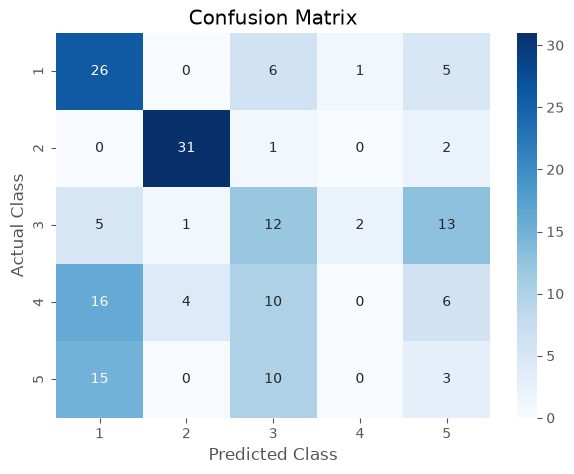

In [55]:
# 4 - running the k-NN model and making a confusion table
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

#running the model on the validation set:
classification_model = KNeighborsClassifier(n_neighbors= 7)
classification_model.fit(eval_feat_train_scaled, eval_target_train)

predicted_target = classification_model.predict(eval_feat_valid_scaled)
actual_target = eval_target_valid

conf_matrix = confusion_matrix(actual_target, predicted_target)
print(conf_matrix)

fig, ax = plt.subplots(figsize = (7,5))
label = [1, 2, 3, 4, 5]
sns.heatmap(data = conf_matrix, xticklabels= label, yticklabels= label, annot = True, fmt = 'd', cmap = 'Blues', ax = ax)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('Actual Class')

plt.show

# using info from https://www.kaggle.com/code/kadriyeaksakal/confusion-matrix-with-knn-algorithm and https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html and https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html

# 4 - accuracy:
accuracy = accuracy_score(y_true = actual_target, y_pred= predicted_target)
acc_percent = accuracy * 100
print(f"This model is {acc_percent:.2f}% accurate.")

# the model is about 43% accurate. Based on the confusion matrix, the model is the most accurate with predicting Mine Type 2 and least accurate predicting mine type 4 and 5.

# 5 - advice with using predictive model in practice:
# I would advise to not blindly trust the output of this model. I recommend that the user looks at the probability distribution for the prediction in order to make an educated guess on what the mine type could be.
# Additionally, keep in mind the cost of making a mistake with assigning the mine the wrong type. 

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]